Train a pure MLP on extracted NUS-WIDE low-level features.

This script is designed for feature files exported by
extract_nuswide_low_level_features.py, especially:
- normalized_all_features.npy
- normalized_<feature_name>.npy

The training log is intentionally kept close to the notebook format:

Epoch 0
Train Loss: 0.1234

Val Loss:   0.2345

Accuracy:   0.0000

F1-micro:   0.5678

F1-macro:   0.3456

mAP:        0.4567

Example-F1: 0.5678

Jaccard:    0.4567

P@K:        0.3456

R@K:        0.2345


In [1]:

from __future__ import annotations

import argparse
import json
import random
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import average_precision_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset

import sys

In [2]:
DEFAULT_TRAIN_FEATURES = [
    Path("dataset/Extracted_Features/Normalized_CORR.npy"),
    Path("dataset/Extracted_Features/Normalized_WT.npy"),
    Path("dataset/Extracted_Features/Normalized_CH.npy"),
    Path("dataset/Extracted_Features/Normalized_EDH.npy"),
    Path("dataset/Extracted_Features/Normalized_CM55.npy"),
    Path("dataset/Extracted_Features/BoW_int.npy"),
]
DEFAULT_TRAIN_LABELS = Path("dataset/database_labels.npy")
DEFAULT_TEST_FEATURES = [
    Path("dataset/Extracted_Features_Test/Normalized_CORR.npy"),
    Path("dataset/Extracted_Features_Test/Normalized_WT.npy"),
    Path("dataset/Extracted_Features_Test/Normalized_CH.npy"),
    Path("dataset/Extracted_Features_Test/Normalized_EDH.npy"),
    Path("dataset/Extracted_Features_Test/Normalized_CM55.npy"),
    Path("dataset/Extracted_Features_Test/BoW_int.npy"),
]
DEFAULT_TEST_LABELS = Path("dataset/test_labels.npy")

In [3]:
@dataclass
class Config:
    train_features: list[Path]
    train_labels: Path
    val_features: list[Path] | None
    val_labels: Path | None
    test_features: list[Path] | None
    test_labels: Path | None
    batch_size: int
    epochs: int
    lr: float
    weight_decay: float
    hidden_dims: list[int]
    dropout: float
    activation: str
    loss: str
    focal_gamma: float
    focal_alpha: float
    asl_gamma_neg: float
    asl_gamma_pos: float
    asl_clip: float
    threshold: float
    top_k: int
    val_ratio: float
    random_seed: int
    num_workers: int
    device: str
    standardize: bool
    scaler_path: Path | None
    selection_metric: str
    save_dir: Path
    save_name: str

In [4]:
class FeatureDataset(Dataset):
    def __init__(self, x: np.ndarray, y: np.ndarray):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self) -> int:
        return len(self.x)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        return self.x[idx], self.y[idx]

In [5]:
class PureMLP(nn.Module):
    def __init__(
        self,
        input_dim: int,
        hidden_dims: list[int],
        output_dim: int,
        dropout: float,
        activation: str,
    ):
        super().__init__()

        act_layer = {
            "relu": nn.ReLU,
            "gelu": nn.GELU,
            "silu": nn.SiLU,
        }[activation]

        layers: list[nn.Module] = []
        prev_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(act_layer())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev_dim = hidden_dim
        layers.append(nn.Linear(prev_dim, output_dim))

        self.network = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)

In [6]:
class FocalLoss(nn.Module):
    def __init__(self, gamma: float = 2.0, alpha: float = 0.25):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        probas = torch.sigmoid(logits)
        pt = probas * targets + (1.0 - probas) * (1.0 - targets)
        alpha_factor = self.alpha * targets + (1.0 - self.alpha) * (1.0 - targets)
        focal_weight = alpha_factor * (1.0 - pt).pow(self.gamma)
        return (focal_weight * bce).mean()

In [7]:
class AsymmetricLoss(nn.Module):
    def __init__(self, gamma_neg: float = 4.0, gamma_pos: float = 1.0, clip: float = 0.05):
        super().__init__()
        self.gamma_neg = gamma_neg
        self.gamma_pos = gamma_pos
        self.clip = clip

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        probas = torch.sigmoid(logits)
        xs_pos = probas
        xs_neg = 1.0 - probas

        if self.clip > 0:
            xs_neg = torch.clamp(xs_neg + self.clip, max=1.0)

        loss_pos = targets * torch.log(torch.clamp(xs_pos, min=1e-8))
        loss_neg = (1.0 - targets) * torch.log(torch.clamp(xs_neg, min=1e-8))
        loss = loss_pos + loss_neg

        pt = xs_pos * targets + xs_neg * (1.0 - targets)
        gamma = self.gamma_pos * targets + self.gamma_neg * (1.0 - targets)
        one_sided_weight = (1.0 - pt).pow(gamma)
        return -(one_sided_weight * loss).mean()

In [8]:
def parse_args() -> Config:
    parser = argparse.ArgumentParser(description="Train a pure MLP on NUS-WIDE feature vectors.")
    parser.add_argument(
        "--train-features",
        type=Path,
        nargs="+",
        default=DEFAULT_TRAIN_FEATURES,
        help=(
            "One or more training feature files. Multiple files are concatenated along feature dimension. "
            "Defaults to the local NUS-WIDE extracted training features."
        ),
    )
    parser.add_argument(
        "--train-labels",
        type=Path,
        default=DEFAULT_TRAIN_LABELS,
        help="Training labels path (.npy or one-hot .txt). Defaults to DATASET/database_labels.npy.",
    )
    parser.add_argument(
        "--val-features",
        type=Path,
        nargs="+",
        default=None,
        help="Optional validation feature files. Must match the number and order of --train-features when using multiple files.",
    )
    parser.add_argument("--val-labels", type=Path, default=None, help="Optional validation labels path (.npy or one-hot .txt).")
    parser.add_argument(
        "--test-features",
        type=Path,
        nargs="+",
        default=DEFAULT_TEST_FEATURES,
        help="Optional held-out test feature files for final evaluation. Defaults to the local NUS-WIDE test features.",
    )
    parser.add_argument(
        "--test-labels",
        type=Path,
        default=DEFAULT_TEST_LABELS,
        help="Optional held-out test labels path (.npy or one-hot .txt). Defaults to DATASET/test_labels.npy.",
    )
    parser.add_argument("--batch-size", type=int, default=128)
    parser.add_argument("--epochs", type=int, default=100)
    parser.add_argument("--lr", type=float, default=1e-4)
    parser.add_argument("--weight-decay", type=float, default=1e-4)
    parser.add_argument(
        "--hidden-dims",
        type=int,
        nargs="+",
        default=[1024, 512, 256],
        help="Hidden layer sizes for the pure MLP.",
    )
    parser.add_argument("--dropout", type=float, default=0.3)
    parser.add_argument("--activation", choices=("relu", "gelu", "silu"), default="gelu")
    parser.add_argument("--loss", choices=("bce", "focal", "asl"), default="bce")
    parser.add_argument("--focal-gamma", type=float, default=2.0)
    parser.add_argument("--focal-alpha", type=float, default=0.25)
    parser.add_argument("--asl-gamma-neg", type=float, default=4.0)
    parser.add_argument("--asl-gamma-pos", type=float, default=1.0)
    parser.add_argument("--asl-clip", type=float, default=0.05)
    parser.add_argument("--threshold", type=float, default=0.5)
    parser.add_argument("--top-k", type=int, default=5, help="K used for Precision@K and Recall@K.")
    parser.add_argument("--val-ratio", type=float, default=0.2)
    parser.add_argument("--random-seed", type=int, default=42)
    parser.add_argument("--num-workers", type=int, default=0)
    parser.add_argument(
        "--device",
        choices=("auto", "cpu", "cuda", "mps"),
        default="auto",
        help="Training device. auto prefers CUDA, then Apple MPS, then CPU.",
    )
    parser.add_argument(
        "--standardize",
        action="store_true",
        help="Fit StandardScaler on the training split only, then transform train/val features.",
    )
    parser.add_argument(
        "--scaler-path",
        type=Path,
        default=None,
        help="Optional path to save the fitted StandardScaler statistics as a .npz file.",
    )
    parser.add_argument(
        "--selection-metric",
        choices=(
            "val_loss",
            "mAP",
            "f1_macro",
            "f1_micro",
            "example_f1",
            "jaccard",
            "precision_at_k",
            "recall_at_k",
        ),
        default="mAP",
        help="Metric used to select the best checkpoint.",
    )
    parser.add_argument("--save-dir", type=Path, default=Path("mlp_runs"))
    parser.add_argument("--save-name", type=str, default="pure_mlp_best.pt")
    args = parser.parse_args()

    if args.top_k <= 0:
        parser.error("--top-k must be positive.")

    return Config(
        train_features=[path.resolve() for path in args.train_features],
        train_labels=args.train_labels.resolve(),
        val_features=[path.resolve() for path in args.val_features] if args.val_features else None,
        val_labels=args.val_labels.resolve() if args.val_labels else None,
        test_features=[path.resolve() for path in args.test_features] if args.test_features else None,
        test_labels=args.test_labels.resolve() if args.test_labels else None,
        batch_size=args.batch_size,
        epochs=args.epochs,
        lr=args.lr,
        weight_decay=args.weight_decay,
        hidden_dims=args.hidden_dims,
        dropout=args.dropout,
        activation=args.activation,
        loss=args.loss,
        focal_gamma=args.focal_gamma,
        focal_alpha=args.focal_alpha,
        asl_gamma_neg=args.asl_gamma_neg,
        asl_gamma_pos=args.asl_gamma_pos,
        asl_clip=args.asl_clip,
        threshold=args.threshold,
        top_k=args.top_k,
        val_ratio=args.val_ratio,
        random_seed=args.random_seed,
        num_workers=args.num_workers,
        device=args.device,
        standardize=args.standardize,
        scaler_path=args.scaler_path.resolve() if args.scaler_path else None,
        selection_metric=args.selection_metric,
        save_dir=args.save_dir.resolve(),
        save_name=args.save_name,
    )

In [9]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [10]:
def load_array(path: Path) -> np.ndarray:
    if path.suffix == ".npy":
        return np.load(path, allow_pickle=False)
    if path.suffix == ".txt":
        return np.loadtxt(path, dtype=np.float32)
    raise ValueError(f"Unsupported file type: {path}")

In [11]:
def load_labels(path: Path) -> np.ndarray:
    labels = load_array(path).astype(np.float32)
    if labels.ndim == 1:
        labels = labels[:, None]
    return labels

In [12]:
def load_feature_matrix(paths: list[Path]) -> np.ndarray:
    arrays: list[np.ndarray] = []
    row_count: int | None = None
    for path in paths:
        features = load_array(path).astype(np.float32)
        if features.ndim != 2:
            raise ValueError(f"Expected a 2D feature array, got shape {features.shape} from {path}")
        if row_count is None:
            row_count = features.shape[0]
        elif features.shape[0] != row_count:
            raise ValueError(
                f"Feature row mismatch while concatenating: expected {row_count}, got {features.shape[0]} from {path}"
            )
        arrays.append(features)
    if not arrays:
        raise ValueError("At least one feature file must be provided.")
    if len(arrays) == 1:
        return arrays[0]
    return np.concatenate(arrays, axis=1)

In [13]:
def maybe_standardize(
    x_train: np.ndarray,
    x_val: np.ndarray,
    enabled: bool,
    scaler_path: Path | None,
) -> tuple[np.ndarray, np.ndarray, StandardScaler | None]:
    if not enabled:
        return x_train.astype(np.float32), x_val.astype(np.float32), None

    scaler = StandardScaler()
    x_train = scaler.fit_transform(x_train).astype(np.float32)
    x_val = scaler.transform(x_val).astype(np.float32)

    if scaler_path is not None:
        scaler_path.parent.mkdir(parents=True, exist_ok=True)
        np.savez_compressed(
            scaler_path,
            mean=scaler.mean_.astype(np.float32),
            scale=scaler.scale_.astype(np.float32),
            var=scaler.var_.astype(np.float32),
        )

    return x_train, x_val, scaler

In [14]:
def build_dataloaders(
    config: Config,
) -> tuple[DataLoader, DataLoader, DataLoader | None, int, int]:
    x_train_all = load_feature_matrix(config.train_features)
    y_train_all = load_labels(config.train_labels)

    if len(x_train_all) != len(y_train_all):
        raise ValueError(
            f"Training feature/label size mismatch: {len(x_train_all)} vs {len(y_train_all)}"
        )

    if config.val_features is not None or config.val_labels is not None:
        if config.val_features is None or config.val_labels is None:
            raise ValueError("Both --val-features and --val-labels must be provided together.")
        x_val = load_feature_matrix(config.val_features)
        y_val = load_labels(config.val_labels)
        if len(x_val) != len(y_val):
            raise ValueError(f"Validation feature/label size mismatch: {len(x_val)} vs {len(y_val)}")
        x_train, y_train = x_train_all, y_train_all
    else:
        x_train, x_val, y_train, y_val = train_test_split(
            x_train_all,
            y_train_all,
            test_size=config.val_ratio,
            random_state=config.random_seed,
            shuffle=True,
        )

    x_train, x_val, scaler = maybe_standardize(
        x_train=x_train,
        x_val=x_val,
        enabled=config.standardize,
        scaler_path=config.scaler_path,
    )

    train_dataset = FeatureDataset(x_train, y_train)
    val_dataset = FeatureDataset(x_val, y_val)

    train_loader = DataLoader(
        train_dataset,
        batch_size=config.batch_size,
        shuffle=True,
        num_workers=config.num_workers,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=config.batch_size,
        shuffle=False,
        num_workers=config.num_workers,
    )

    test_loader: DataLoader | None = None
    if config.test_features is not None or config.test_labels is not None:
        if config.test_features is None or config.test_labels is None:
            raise ValueError("Both --test-features and --test-labels must be provided together.")
        x_test = load_feature_matrix(config.test_features)
        y_test = load_labels(config.test_labels)
        if len(x_test) != len(y_test):
            raise ValueError(f"Test feature/label size mismatch: {len(x_test)} vs {len(y_test)}")
        if scaler is not None:
            x_test = scaler.transform(x_test).astype(np.float32)
        else:
            x_test = x_test.astype(np.float32)
        test_dataset = FeatureDataset(x_test, y_test)
        test_loader = DataLoader(
            test_dataset,
            batch_size=config.batch_size,
            shuffle=False,
            num_workers=config.num_workers,
        )

    return train_loader, val_loader, test_loader, x_train.shape[1], y_train.shape[1]

In [15]:
def macro_average_precision(y_true: np.ndarray, y_prob: np.ndarray) -> float:
    ap_scores: list[float] = []
    for label_index in range(y_true.shape[1]):
        if np.sum(y_true[:, label_index]) == 0:
            continue
        ap_scores.append(float(average_precision_score(y_true[:, label_index], y_prob[:, label_index])))
    if not ap_scores:
        return 0.0
    return float(np.mean(ap_scores))

In [16]:
def example_based_f1(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    intersection = np.sum(y_true * y_pred, axis=1)
    pred_count = np.sum(y_pred, axis=1)
    true_count = np.sum(y_true, axis=1)
    denominator = pred_count + true_count
    scores = np.divide(
        2.0 * intersection,
        denominator,
        out=np.ones_like(intersection, dtype=np.float32),
        where=denominator != 0,
    )
    return float(np.mean(scores))

In [17]:
def example_based_jaccard(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    intersection = np.sum(y_true * y_pred, axis=1)
    union = np.sum(np.maximum(y_true, y_pred), axis=1)
    scores = np.divide(
        intersection,
        union,
        out=np.ones_like(intersection, dtype=np.float32),
        where=union != 0,
    )
    return float(np.mean(scores))

In [18]:
def precision_recall_at_k(y_true: np.ndarray, y_prob: np.ndarray, k: int) -> tuple[float, float]:
    if k <= 0:
        raise ValueError(f"--top-k must be positive, got {k}")

    k = min(k, y_prob.shape[1])
    top_indices = np.argpartition(-y_prob, kth=k - 1, axis=1)[:, :k]
    top_hits = np.take_along_axis(y_true, top_indices, axis=1).sum(axis=1)
    true_count = y_true.sum(axis=1)

    precision_at_k = np.mean(top_hits / k)
    recall_at_k = np.mean(
        np.divide(
            top_hits,
            true_count,
            out=np.zeros_like(top_hits, dtype=np.float32),
            where=true_count != 0,
        )
    )

    return float(precision_at_k), float(recall_at_k)

In [19]:
def train_one_epoch(
    model: nn.Module,
    dataloader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    device: torch.device,
) -> float:
    model.train()
    total_loss = 0.0

    for x, y in dataloader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / max(len(dataloader), 1)

In [20]:
def evaluate(
    model: nn.Module,
    dataloader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
    threshold: float,
    top_k: int,
) -> dict[str, float]:
    model.eval()
    total_loss = 0.0
    all_targets: list[np.ndarray] = []
    all_probs: list[np.ndarray] = []
    all_preds: list[np.ndarray] = []

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x)
            loss = criterion(logits, y)
            probs = torch.sigmoid(logits)
            preds = (probs > threshold).float()

            total_loss += loss.item()
            all_targets.append(y.cpu().numpy())
            all_probs.append(probs.cpu().numpy())
            all_preds.append(preds.cpu().numpy())

    y_true = np.vstack(all_targets)
    y_prob = np.vstack(all_probs)
    y_pred = np.vstack(all_preds)

    exact_match_accuracy = (y_pred == y_true).all(axis=1).mean()
    f1_micro = f1_score(y_true, y_pred, average="micro", zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
    mAP = macro_average_precision(y_true, y_prob)
    example_f1 = example_based_f1(y_true, y_pred)
    jaccard = example_based_jaccard(y_true, y_pred)
    precision_at_k, recall_at_k = precision_recall_at_k(y_true, y_prob, top_k)

    return {
        "loss": total_loss / max(len(dataloader), 1),
        "accuracy": float(exact_match_accuracy),
        "f1_micro": float(f1_micro),
        "f1_macro": float(f1_macro),
        "mAP": float(mAP),
        "example_f1": float(example_f1),
        "jaccard": float(jaccard),
        "precision_at_k": float(precision_at_k),
        "recall_at_k": float(recall_at_k),
    }


In [21]:
def build_criterion(config: Config) -> nn.Module:
    if config.loss == "bce":
        return nn.BCEWithLogitsLoss()
    if config.loss == "focal":
        return FocalLoss(gamma=config.focal_gamma, alpha=config.focal_alpha)
    if config.loss == "asl":
        return AsymmetricLoss(
            gamma_neg=config.asl_gamma_neg,
            gamma_pos=config.asl_gamma_pos,
            clip=config.asl_clip,
        )
    raise ValueError(f"Unsupported loss: {config.loss}")

In [22]:
def build_device(device_name: str) -> torch.device:
    mps_available = hasattr(torch.backends, "mps") and torch.backends.mps.is_available()

    if device_name == "auto":
        if torch.cuda.is_available():
            return torch.device("cuda")
        if mps_available:
            return torch.device("mps")
        return torch.device("cpu")

    if device_name == "cuda" and not torch.cuda.is_available():
        raise RuntimeError("CUDA was requested with --device cuda, but torch.cuda.is_available() is false.")
    if device_name == "mps" and not mps_available:
        raise RuntimeError("MPS was requested with --device mps, but torch.backends.mps.is_available() is false.")

    return torch.device(device_name)

In [23]:
def is_improvement(metric_name: str, current: float, best: float) -> bool:
    if metric_name == "val_loss":
        return current < best
    return current > best

In [24]:
def save_checkpoint(
    save_path: Path,
    model: nn.Module,
    config: Config,
    input_dim: int,
    num_labels: int,
    best_score: float,
) -> None:
    save_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "config": {
                "input_dim": input_dim,
                "num_labels": num_labels,
                "hidden_dims": config.hidden_dims,
                "dropout": config.dropout,
                "activation": config.activation,
                "loss": config.loss,
                "threshold": config.threshold,
                "top_k": config.top_k,
            },
            "best_score": best_score,
            "selection_metric": config.selection_metric,
        },
        save_path,
    )

In [25]:
def run_experiment(config: Config) -> dict[str, float] | None:
    set_seed(config.random_seed)

    train_loader, val_loader, test_loader, input_dim, num_labels = build_dataloaders(config)

    device = build_device(config.device)
    print(f"Using device: {device}")
    print(f"Loss: {config.loss}")
    print(f"Save dir: {config.save_dir}")

    model = PureMLP(
        input_dim=input_dim,
        hidden_dims=config.hidden_dims,
        output_dim=num_labels,
        dropout=config.dropout,
        activation=config.activation,
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config.lr,
        weight_decay=config.weight_decay,
    )
    criterion = build_criterion(config)

    save_path = config.save_dir / config.save_name
    metrics_history: list[dict[str, float]] = []
    best_score = float("inf") if config.selection_metric == "val_loss" else float("-inf")

    for epoch in range(config.epochs):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_metrics = evaluate(
            model=model,
            dataloader=val_loader,
            criterion=criterion,
            device=device,
            threshold=config.threshold,
            top_k=config.top_k,
        )

        print(
            f"""
Epoch {epoch}
Train Loss: {train_loss:.4f}
Val Loss:   {val_metrics['loss']:.4f}
Accuracy:   {val_metrics['accuracy']:.4f}
F1-micro:   {val_metrics['f1_micro']:.4f}
F1-macro:   {val_metrics['f1_macro']:.4f}
mAP:        {val_metrics['mAP']:.4f}
Example-F1: {val_metrics['example_f1']:.4f}
Jaccard:    {val_metrics['jaccard']:.4f}
P@{config.top_k}:        {val_metrics['precision_at_k']:.4f}
R@{config.top_k}:        {val_metrics['recall_at_k']:.4f}
"""
        )

        metrics_history.append(
            {
                "epoch": epoch,
                "train_loss": float(train_loss),
                "val_loss": float(val_metrics["loss"]),
                "accuracy": float(val_metrics["accuracy"]),
                "f1_micro": float(val_metrics["f1_micro"]),
                "f1_macro": float(val_metrics["f1_macro"]),
                "mAP": float(val_metrics["mAP"]),
                "example_f1": float(val_metrics["example_f1"]),
                "jaccard": float(val_metrics["jaccard"]),
                "precision_at_k": float(val_metrics["precision_at_k"]),
                "recall_at_k": float(val_metrics["recall_at_k"]),
                "top_k": config.top_k,
            }
        )

        current_score = {
            "val_loss": val_metrics["loss"],
            "mAP": val_metrics["mAP"],
            "f1_macro": val_metrics["f1_macro"],
            "f1_micro": val_metrics["f1_micro"],
            "example_f1": val_metrics["example_f1"],
            "jaccard": val_metrics["jaccard"],
            "precision_at_k": val_metrics["precision_at_k"],
            "recall_at_k": val_metrics["recall_at_k"],
        }[config.selection_metric]

        if is_improvement(config.selection_metric, current_score, best_score):
            best_score = current_score
            save_checkpoint(
                save_path=save_path,
                model=model,
                config=config,
                input_dim=input_dim,
                num_labels=num_labels,
                best_score=best_score,
            )

    config.save_dir.mkdir(parents=True, exist_ok=True)
    history_path = config.save_dir / "training_history.json"
    history_path.write_text(json.dumps(metrics_history, indent=2), encoding="utf-8")

    if test_loader is None:
        return None

    checkpoint = torch.load(save_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    test_metrics = evaluate(
        model=model,
        dataloader=test_loader,
        criterion=criterion,
        device=device,
        threshold=config.threshold,
        top_k=config.top_k,
    )
    test_metrics["top_k"] = config.top_k

    (config.save_dir / "test_metrics.json").write_text(
        json.dumps(test_metrics, indent=2),
        encoding="utf-8",
    )

    print(
        f"""
Best Checkpoint ({config.selection_metric})
Test Loss:  {test_metrics['loss']:.4f}
Accuracy:   {test_metrics['accuracy']:.4f}
F1-micro:   {test_metrics['f1_micro']:.4f}
F1-macro:   {test_metrics['f1_macro']:.4f}
mAP:        {test_metrics['mAP']:.4f}
Example-F1: {test_metrics['example_f1']:.4f}
Jaccard:    {test_metrics['jaccard']:.4f}
P@{config.top_k}:        {test_metrics['precision_at_k']:.4f}
R@{config.top_k}:        {test_metrics['recall_at_k']:.4f}
"""
    )

    return test_metrics


In [26]:
base_config = dict(
    train_features=DEFAULT_TRAIN_FEATURES,
    train_labels=DEFAULT_TRAIN_LABELS,
    val_features=None,
    val_labels=None,
    test_features=DEFAULT_TEST_FEATURES,
    test_labels=DEFAULT_TEST_LABELS,
    batch_size=32,
    epochs=50,
    lr=1e-4,
    weight_decay=1e-5,
    hidden_dims=[1024, 512, 256],
    dropout=0.3,
    activation="gelu",
    threshold=0.5,
    top_k=5,
    val_ratio=0.2,
    random_seed=42,
    num_workers=0,
    device="cuda",
    standardize=False,
    scaler_path=None,
    selection_metric="mAP",
    save_name="pure_mlp_best.pt",
)


In [27]:
bce_config = Config(
    **base_config,
    loss="bce",
    focal_gamma=2.0,
    focal_alpha=0.25,
    asl_gamma_neg=4.0,
    asl_gamma_pos=1.0,
    asl_clip=0.05, 
    save_dir=Path("mlp_runs_bce"),
)

bce_metrics = run_experiment(bce_config)

Using device: cuda
Loss: bce
Save dir: mlp_runs_bce

Epoch 0
Train Loss: 0.2037
Val Loss:   0.1777
Accuracy:   0.2857
F1-micro:   0.5803
F1-macro:   0.3232
mAP:        0.4821
Example-F1: 0.5194
Jaccard:    0.4615
P@5:        0.3402
R@5:        0.8554


Epoch 1
Train Loss: 0.1780
Val Loss:   0.1699
Accuracy:   0.2994
F1-micro:   0.6046
F1-macro:   0.3714
mAP:        0.5177
Example-F1: 0.5468
Jaccard:    0.4861
P@5:        0.3461
R@5:        0.8665


Epoch 2
Train Loss: 0.1695
Val Loss:   0.1663
Accuracy:   0.3094
F1-micro:   0.6150
F1-macro:   0.3988
mAP:        0.5364
Example-F1: 0.5566
Jaccard:    0.4966
P@5:        0.3489
R@5:        0.8736


Epoch 3
Train Loss: 0.1636
Val Loss:   0.1647
Accuracy:   0.3189
F1-micro:   0.6271
F1-macro:   0.4300
mAP:        0.5444
Example-F1: 0.5738
Jaccard:    0.5123
P@5:        0.3497
R@5:        0.8753


Epoch 4
Train Loss: 0.1581
Val Loss:   0.1634
Accuracy:   0.3214
F1-micro:   0.6343
F1-macro:   0.4434
mAP:        0.5498
Example-F1: 0.5802
Jaccar

In [28]:
focal_config = Config(
    **base_config,
    loss="focal",
    focal_gamma=2.0,
    focal_alpha=0.25,
    asl_gamma_neg=4.0,
    asl_gamma_pos=1.0,
    asl_clip=0.05,
    save_dir=Path("mlp_runs_focal_g2_a025"),
)

focal_metrics = run_experiment(focal_config)

Using device: cuda
Loss: focal
Save dir: mlp_runs_focal_g2_a025

Epoch 0
Train Loss: 0.0205
Val Loss:   0.0177
Accuracy:   0.1814
F1-micro:   0.4186
F1-macro:   0.1911
mAP:        0.4897
Example-F1: 0.3230
Jaccard:    0.2858
P@5:        0.3410
R@5:        0.8571


Epoch 1
Train Loss: 0.0179
Val Loss:   0.0171
Accuracy:   0.2026
F1-micro:   0.4574
F1-macro:   0.2189
mAP:        0.5231
Example-F1: 0.3632
Jaccard:    0.3213
P@5:        0.3465
R@5:        0.8676


Epoch 2
Train Loss: 0.0171
Val Loss:   0.0168
Accuracy:   0.2053
F1-micro:   0.4567
F1-macro:   0.2293
mAP:        0.5395
Example-F1: 0.3595
Jaccard:    0.3199
P@5:        0.3490
R@5:        0.8739


Epoch 3
Train Loss: 0.0165
Val Loss:   0.0166
Accuracy:   0.2224
F1-micro:   0.4806
F1-macro:   0.2538
mAP:        0.5470
Example-F1: 0.3861
Jaccard:    0.3443
P@5:        0.3499
R@5:        0.8763


Epoch 4
Train Loss: 0.0160
Val Loss:   0.0165
Accuracy:   0.2322
F1-micro:   0.5015
F1-macro:   0.2763
mAP:        0.5501
Example-F1: 0

In [29]:
asl_config = Config(
    **base_config,
    loss="asl",
    focal_gamma=2.0,
    focal_alpha=0.25,
    asl_gamma_neg=4.0,
    asl_gamma_pos=1.0,
    asl_clip=0.05,
    save_dir=Path("mlp_runs_asl_gn4_gp1_c005"),
)

asl_metrics = run_experiment(asl_config)

Using device: cuda
Loss: asl
Save dir: mlp_runs_asl_gn4_gp1_c005

Epoch 0
Train Loss: 0.0350
Val Loss:   0.0317
Accuracy:   0.1474
F1-micro:   0.5833
F1-macro:   0.4815
mAP:        0.5035
Example-F1: 0.5901
Jaccard:    0.4741
P@5:        0.3432
R@5:        0.8615


Epoch 1
Train Loss: 0.0317
Val Loss:   0.0307
Accuracy:   0.1686
F1-micro:   0.6002
F1-macro:   0.5056
mAP:        0.5311
Example-F1: 0.6074
Jaccard:    0.4947
P@5:        0.3476
R@5:        0.8700


Epoch 2
Train Loss: 0.0304
Val Loss:   0.0303
Accuracy:   0.1841
F1-micro:   0.6114
F1-macro:   0.5163
mAP:        0.5441
Example-F1: 0.6181
Jaccard:    0.5079
P@5:        0.3495
R@5:        0.8748


Epoch 3
Train Loss: 0.0294
Val Loss:   0.0301
Accuracy:   0.1784
F1-micro:   0.6105
F1-macro:   0.5199
mAP:        0.5505
Example-F1: 0.6167
Jaccard:    0.5052
P@5:        0.3501
R@5:        0.8765


Epoch 4
Train Loss: 0.0285
Val Loss:   0.0300
Accuracy:   0.2017
F1-micro:   0.6145
F1-macro:   0.5218
mAP:        0.5530
Example-F1: 

In [30]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

run_dirs = {
    "BCE": Path("mlp_runs_bce"),
    "Focal": Path("mlp_runs_focal_g2_a025"),
    "ASL": Path("mlp_runs_asl_gn4_gp1_c005"),
}

histories = {}

for name, run_dir in run_dirs.items():
    history_path = run_dir / "training_history.json"
    if history_path.exists():
        with open(history_path, "r") as f:
            histories[name] = pd.DataFrame(json.load(f))
    else:
        print(f"Missing: {history_path}")


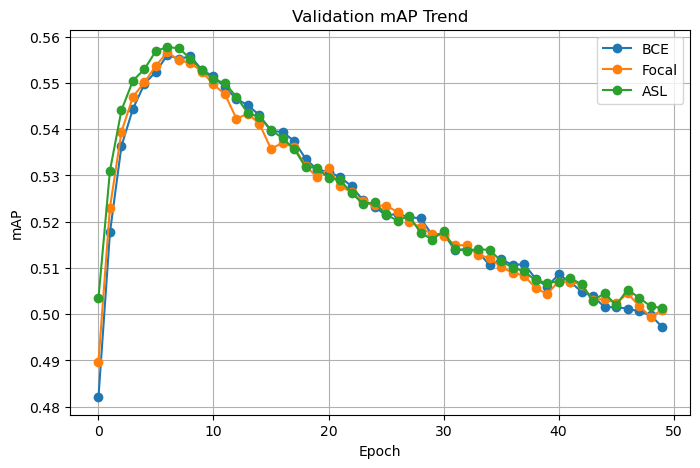

In [31]:
plt.figure(figsize=(8, 5))

for name, df in histories.items():
    plt.plot(df["epoch"], df["mAP"], marker="o", label=name)

plt.xlabel("Epoch")
plt.ylabel("mAP")
plt.title("Validation mAP Trend")
plt.legend()
plt.grid(True)
plt.show()


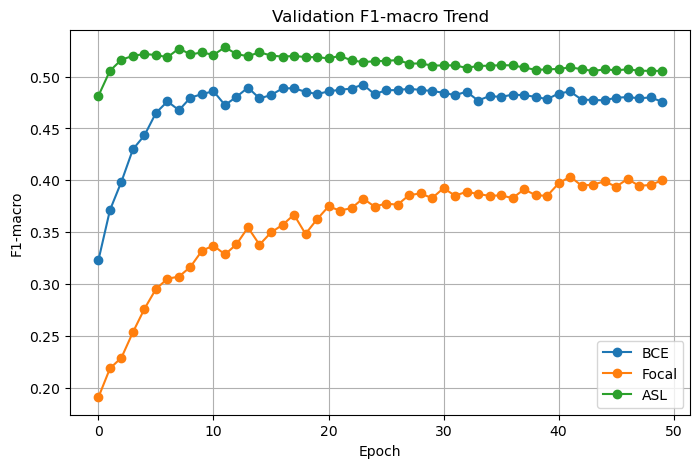

In [32]:
plt.figure(figsize=(8, 5))

for name, df in histories.items():
    plt.plot(df["epoch"], df["f1_macro"], marker="o", label=name)

plt.xlabel("Epoch")
plt.ylabel("F1-macro")
plt.title("Validation F1-macro Trend")
plt.legend()
plt.grid(True)
plt.show()


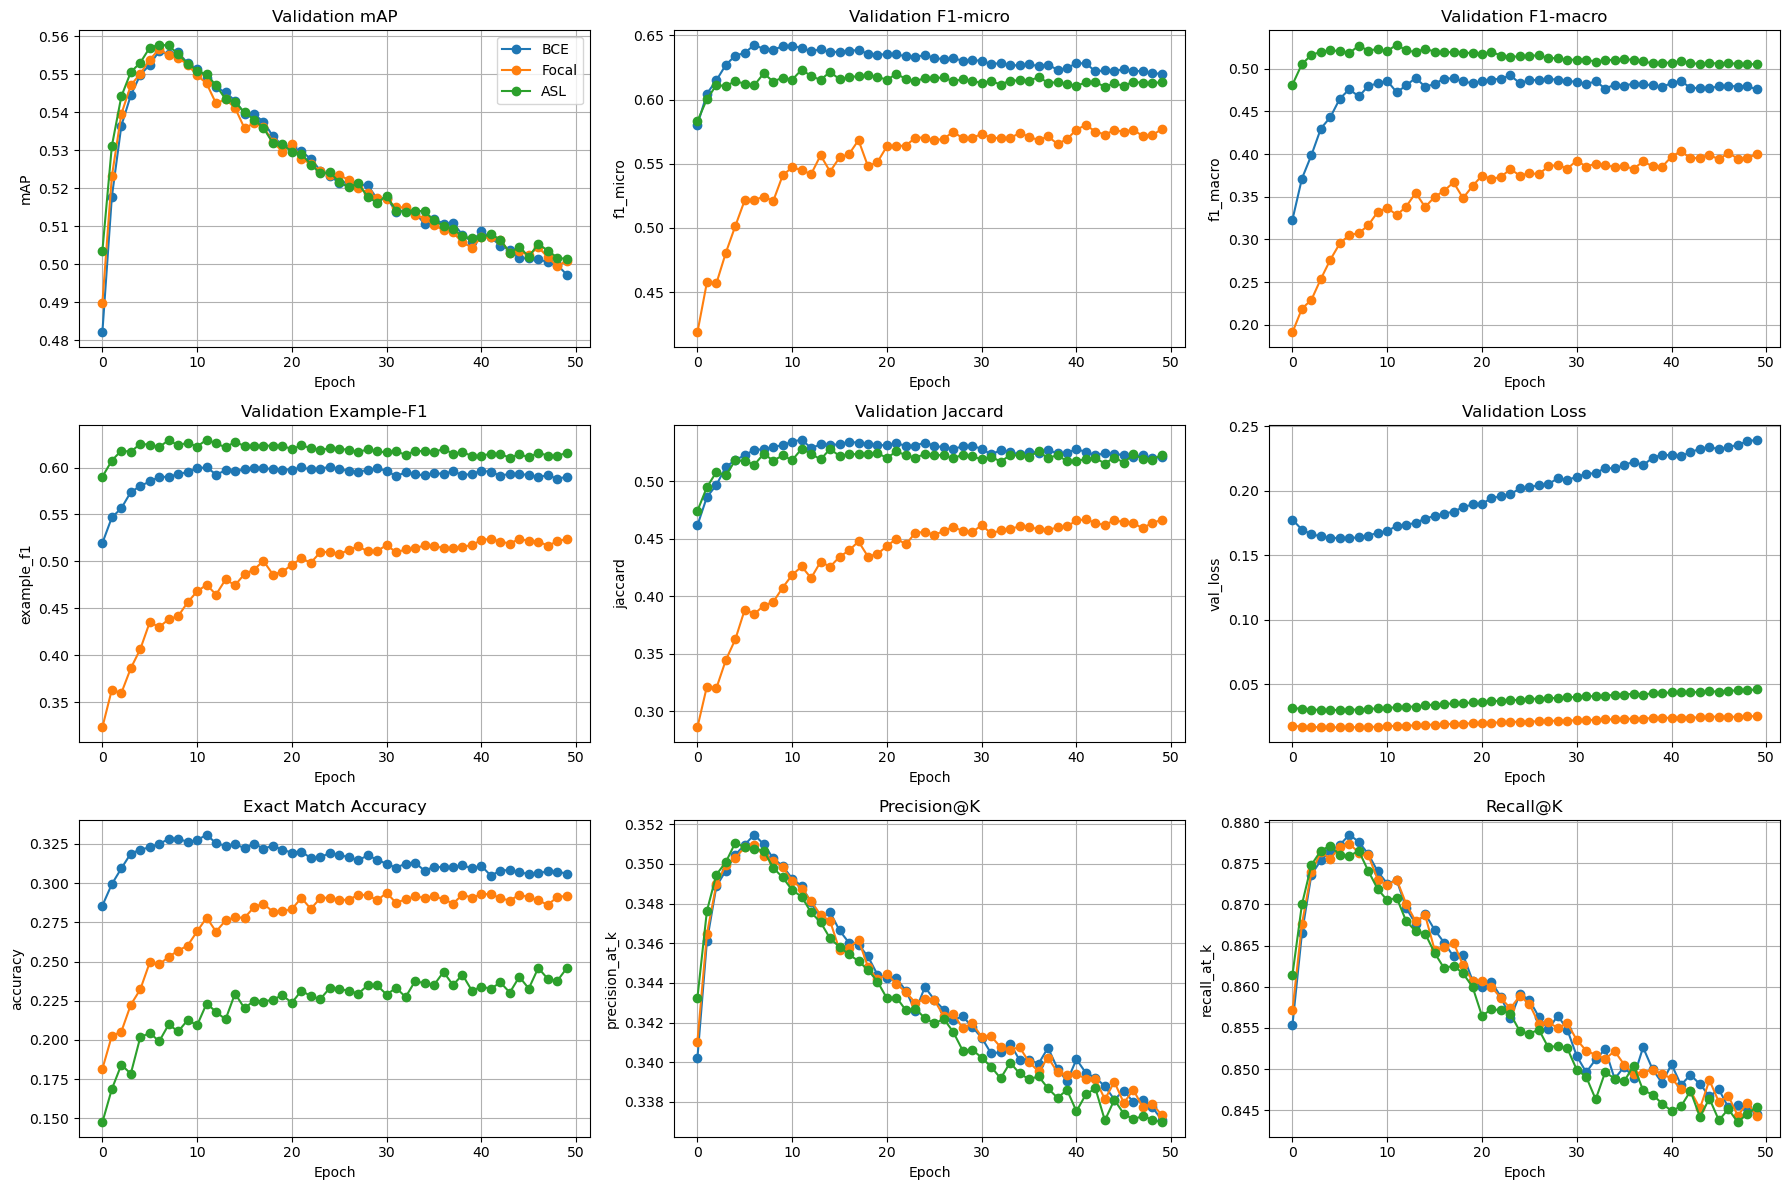

In [33]:
metrics = [
    ("mAP", "Validation mAP"),
    ("f1_micro", "Validation F1-micro"),
    ("f1_macro", "Validation F1-macro"),
    ("example_f1", "Validation Example-F1"),
    ("jaccard", "Validation Jaccard"),
    ("val_loss", "Validation Loss"),
    ("accuracy", "Exact Match Accuracy"),
    ("precision_at_k", "Precision@K"),
    ("recall_at_k", "Recall@K"),
]

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, (metric, title) in zip(axes, metrics):
    for name, df in histories.items():
        if metric in df.columns:
            ax.plot(df["epoch"], df[metric], marker="o", label=name)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(metric)
    ax.grid(True)

axes[0].legend()
plt.tight_layout()
plt.show()
